In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib import pyplot as plt
import seaborn as sns

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

## select a gene module from GO graph

In [ ]:
gograph_dict = pd.read_pickle("raw/gene2go_all.pkl")

In [ ]:
from scipy.sparse import coo_matrix

all_genes = sorted(gograph_dict.keys())
all_gos = sorted(set(go for goset in gograph_dict.values() for go in goset))

gene_to_idx = {gene: idx for idx, gene in enumerate(all_genes)}
go_to_idx = {go: idx for idx, go in enumerate(all_gos)}

rows = []
cols = []
for gene, goset in gograph_dict.items():
    gene_idx = gene_to_idx[gene]
    for go in goset:
        go_idx = go_to_idx[go]
        cols.append(go_idx)  # GO term as column
        rows.append(gene_idx)  # gene as row

gograph_sparse = coo_matrix(
    (np.ones(len(rows), dtype=bool), (rows, cols)),
    shape=(len(all_genes), len(all_gos))
).tocsr() 


gograph_ad = sc.AnnData(
    X=gograph_sparse,
    var=pd.DataFrame(index=all_gos),
    obs=pd.DataFrame(index=all_genes)
)

In [43]:
gograph_ad.write_h5ad("gograph_ad.h5ad")

## filter genes not in examplar

In [44]:
gograph_ad = sc.read_h5ad("gograph_ad.h5ad")

In [45]:
examplar_ad = sc.read_h5ad("../norman/preprocessed.h5ad")
examplar_ad = examplar_ad[examplar_ad.obs['perturbation']=='control'].copy()
examplar_ad.X = examplar_ad.layers['raw']
sc.pp.filter_cells(examplar_ad, min_counts=100)
sc.pp.filter_genes(examplar_ad, min_cells=10)
genes = np.intersect1d(gograph_ad.obs_names, examplar_ad.var_names)
gograph_ad = gograph_ad[genes, :].copy()
examplar_ad = examplar_ad[:, genes].copy()

In [46]:
examplar_ad

AnnData object with n_obs × n_vars = 8395 × 12354
    obs: 'guide_id', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_counts', 'n_genes'
    var: 'ensemble_id', 'ncounts', 'ncells', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_raw', 'highly_variable_batch'
    uns: 'hvg', 'log1p'
    layers: 'raw'

In [ ]:
# Estimate average counts, dispersions, and dropout rates using Maximum Likelihood Estimate (MLE)
import scipy.sparse as sp

# Extract matrix (cells x genes)
X = examplar_ad.X.toarray() if sp.issparse(examplar_ad.X) else examplar_ad.X

# MLE for mean (lambda) of a Poisson: sample mean
mean_counts = X.mean(axis=0)

# MLE for dispersion for NB: sample variance (sigma^2) and sample mean (mu),
# NB dispersion (alpha): alpha = (var - mean) / mean^2, constrained to >=0
variance = X.var(axis=0, ddof=0)
dispersion = np.maximum((mean_counts ** 2) / (variance - mean_counts + 1e-10), 1e-10)
# dispersion = np.maximum((variance - mean_counts) / (mean_counts ** 2 + 1e-10), 1e-4) ## Incorrect !!!

# MLE for dropout rate (Bernoulli 'p'): fraction of zeros
dropout_rate = (X == 0).sum(axis=0) / X.shape[0]

# Assign to gograph_ad.obs
gograph_ad.obs['average_counts.simple'] = mean_counts
gograph_ad.obs['dispersions.simple'] = dispersion
gograph_ad.obs['dropout_rates.simple'] = dropout_rate

In [124]:
np.savez_compressed(
    'data/examplar_counts.npz', 
    X=examplar_ad.X.toarray()
)

np.savez_compressed(
    'data/examplar_zinb_simple_params.npz', 
    mean_counts=mean_counts, 
    dispersion=dispersion, 
    dropout_rate=dropout_rate
)

In [ ]:
# estimate mean, dispersion, and dropout rate from examplar by SGD
import torch
from torch.utils.data import TensorDataset, DataLoader
from torch import optim, nn
from torch.nn import functional as F
from driver_genes.losses.rec import zinb
import tqdm

# convert parameters' support to [-inf, inf]
params = nn.ParameterList([
    nn.Parameter(torch.log(torch.tensor(mean_counts, dtype=torch.float32).unsqueeze(0))),
    nn.Parameter(torch.log(torch.tensor(dispersion, dtype=torch.float32).unsqueeze(0))),
    nn.Parameter(torch.logit(torch.tensor(dropout_rate, dtype=torch.float32).unsqueeze(0), eps=1e-8))
])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
params = params.to(device)

In [127]:
optimizer = optim.Adam(params, lr=0.001)
# optimizer = optim.SGD(params, lr=0.001)
# optimizer = optim.Muon(params, lr=0.001)

In [128]:
for i, p in enumerate(params):
    print(i, 'original NaN',  torch.isnan(p).sum(), 'original Inf', torch.isinf(p).sum())
    if i != 2:
        print(i, 'softplus NaN', torch.isnan(torch.exp(p)).sum(), 'softplus Inf', torch.isinf(torch.exp(p)).sum())

0 original NaN tensor(0, device='cuda:0') original Inf tensor(0, device='cuda:0')
0 softplus NaN tensor(0, device='cuda:0') softplus Inf tensor(0, device='cuda:0')
1 original NaN tensor(0, device='cuda:0') original Inf tensor(0, device='cuda:0')
1 softplus NaN tensor(0, device='cuda:0') softplus Inf tensor(0, device='cuda:0')
2 original NaN tensor(0, device='cuda:0') original Inf tensor(0, device='cuda:0')


In [129]:
dataset = TensorDataset(torch.tensor(examplar_ad.X.toarray(), dtype=torch.float32))
dataloader = DataLoader(dataset, batch_size=8395, shuffle=True)
inputs = next(iter(dataloader))[0].to(device)
step = 0
best_loss = float('inf')
history = []
progress_bar = tqdm.tqdm(range(20000))
for epoch in progress_bar:
    epoch_history = []
    # for batch in dataloader:
    params_ = (torch.exp(params[0]), torch.exp(params[1]), params[2])
    # loss = zinb(batch[0].to(device), params_)
    loss = zinb(inputs, params_)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    step += 1
    epoch_history.append(loss.item())
    
    # log within epoch
    progress_bar.set_description(f'Epoch {epoch}, Step {step}, Loss {loss.item():.4f}, Best epoch loss {best_loss:.4f}')
    epoch_loss = np.mean(epoch_history)
    history.append(epoch_loss)
    if epoch_loss < best_loss:
        best_loss = epoch_loss
    if len(history) > 0 and np.min(history[-min(20, len(history)):]) > best_loss:
        print(f'Early stopping at epoch {epoch}, step {step}')
        break


Epoch 12570, Step 12571, Loss 9024.9951, Best epoch loss 9024.5527:  63%|██████▎   | 12570/20000 [04:51<02:52, 43.12it/s]

Early stopping at epoch 12570, step 12571


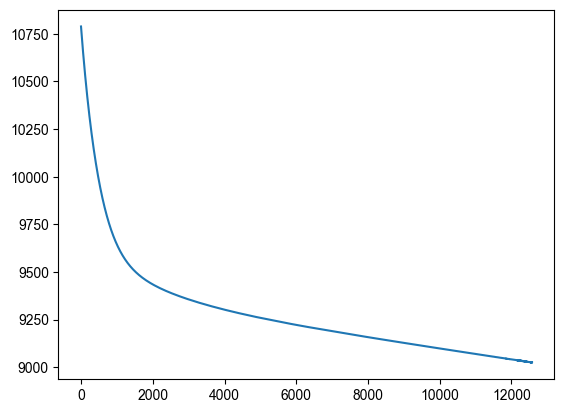

In [130]:
plt.plot(history)
plt.show()


In [131]:
gograph_ad.obs['average_counts.zinb'] = params_[0].detach().cpu().squeeze().numpy()
gograph_ad.obs['dispersions.zinb'] = params_[1].detach().cpu().squeeze().numpy()
gograph_ad.obs['dropout_rates.zinb'] = torch.sigmoid(params_[2]).detach().cpu().squeeze().numpy()

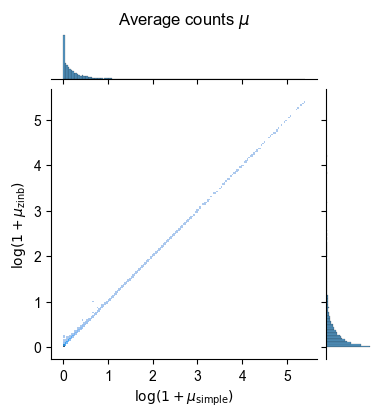

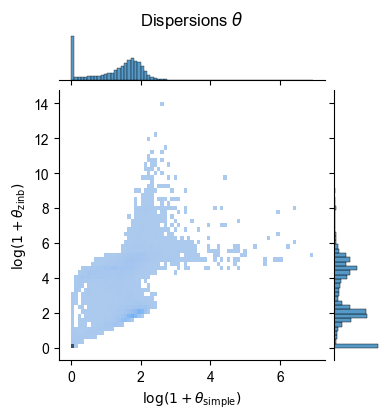

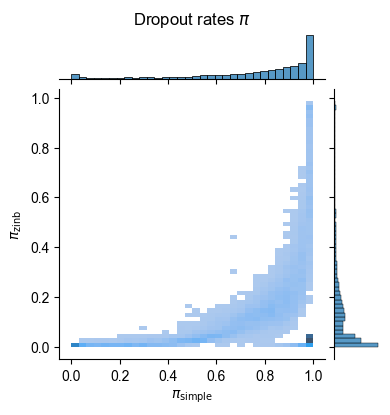

In [ ]:
g = sns.jointplot(
    x=gograph_ad.obs['average_counts.simple'].apply(np.log1p),
    y=gograph_ad.obs['average_counts.zinb'].apply(np.log1p),
    height=4,
    kind='hist',
)
g.set_axis_labels(r'$\log (1+\mu_\text{simple})$', r'$\log (1+\mu_\text{zinb})$')
g.ax_marg_x.set_title(r'Average counts $\mu$')
plt.savefig('figs/gograph_ad_average_counts_simple_vs_zinb.pdf', bbox_inches='tight')
plt.show()

g = sns.jointplot(
    x=gograph_ad.obs['dispersions.simple'].apply(np.log1p),
    y=gograph_ad.obs['dispersions.zinb'].apply(np.log1p),
    height=4,
    kind='hist',
)
g.set_axis_labels(r'$\log (1+\theta_\text{simple})$', r'$\log (1+\theta_\text{zinb})$')
g.ax_marg_x.set_title(r'Dispersions $\theta$')
plt.savefig('figs/gograph_ad_dispersions_simple_vs_zinb.pdf', bbox_inches='tight')
plt.show()

g = sns.jointplot(
    x=gograph_ad.obs['dropout_rates.simple'],
    y=gograph_ad.obs['dropout_rates.zinb'],
    height=4,
    kind='hist',
)
g.set_axis_labels(r'$\pi_\text{simple}$', r'$\pi_\text{zinb}$')
g.ax_marg_x.set_title(r'Dropout rates $\pi$')
# plt.savefig('figs/gograph_ad_dropout_rates_simple_vs_zinb.pdf', bbox_inches='tight')
plt.show()


In [133]:
sc.pp.neighbors(gograph_ad, use_rep='X', n_neighbors=30, metric='jaccard')
sc.tl.umap(gograph_ad)
sc.tl.leiden(gograph_ad, flavor='igraph', n_iterations=2, resolution=0.5)

In [135]:
large_clusts = gograph_ad.obs['leiden'].value_counts()[lambda x: x>500]

In [136]:
large_clusts

leiden
4    2985
2    2251
0    1896
1    1016
8     960
6     845
3     706
7     502
Name: count, dtype: int64

In [137]:
gograph_ad.obs['leiden.filtered'] = gograph_ad.obs['leiden'].apply(lambda x: f'{x} ({large_clusts[x]})' if x in large_clusts else np.nan)

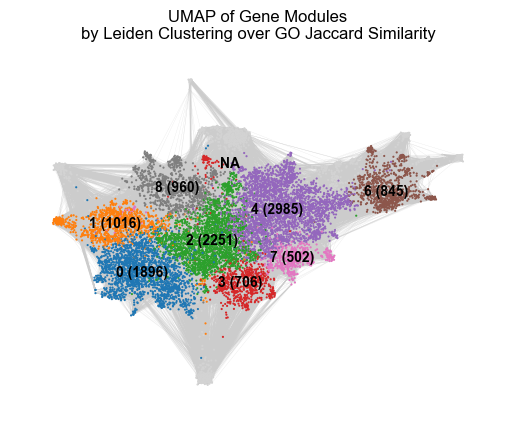

In [138]:
ax = sc.pl.embedding(
    gograph_ad, 
    basis='umap',
    color='leiden.filtered', 
    legend_loc='on data', 
    edges=True,
    edges_color='#cccccc',
    frameon=False, 
    show=False
)
ax.set_title('UMAP of Gene Modules\nby Leiden Clustering over GO Jaccard Similarity')
# plt.savefig('figs/gograph_ad_processed_umap.pdf', bbox_inches='tight')
plt.show()

In [139]:
gograph_ad.write_h5ad("gograph_ad_processed.h5ad")

## Simulate $\log(1+Y)$

In [2]:
gograph_ad = sc.read_h5ad("gograph_ad_processed.h5ad")
gograph_ad

AnnData object with n_obs × n_vars = 12354 × 18644
    obs: 'average_counts.simple', 'dispersions.simple', 'dropout_rates.simple', 'average_counts.zinb', 'dispersions.zinb', 'dropout_rates.zinb', 'leiden', 'leiden.filtered', 'mean_log1p_smp', 'var_log1p_smp'
    uns: 'leiden', 'leiden.filtered_colors', 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'

In [141]:
def sample_zinb(mu, theta, pi, n_celleach):
    """
    mu: mean of the NB distribution (shape: [G])
    theta: dispersion of the NB distribution (shape: [G])
    pi: dropout rate (probability of dropout, shape: [G])
    n_celleach: number of cells to sample
    Returns an array of shape (n_celleach, G), sampled from ZINB
    """
    assert len(mu) == len(theta) == len(pi)
    G = len(mu)
    # Binomial mask: dropout == 1 means DROPOUT (set to zero), 0 means measured (sample NB)
    dropout = np.random.binomial(1, pi, size=(n_celleach, G))
    
    # For entries not dropped out, sample from NB:
    # Conversion from mu/theta to n/p:
    #   n = theta
    #   p = theta / (theta + mu)
    n = theta
    p = theta / (theta + mu)
    n_broadcast = np.broadcast_to(n, (n_celleach, G))
    p_broadcast = np.broadcast_to(p, (n_celleach, G))
    Y_nb = np.random.negative_binomial(n_broadcast, p_broadcast)
    
    # Set to zero where dropout==1
    Y_zinb = Y_nb.copy()
    Y_zinb[dropout == 1] = 0
    return Y_zinb


In [142]:
Y_zinb = sample_zinb(
    gograph_ad.obs['average_counts.zinb'],
    gograph_ad.obs['dispersions.zinb'],
    gograph_ad.obs['dropout_rates.zinb'],
    10000
)

In [143]:
mean_smp = Y_zinb.mean(axis=0)
disp_smp = mean_smp ** 2 / (Y_zinb.var(axis=0) - mean_smp  + 1e-10)
pi_smp = (Y_zinb == 0).mean(axis=0)

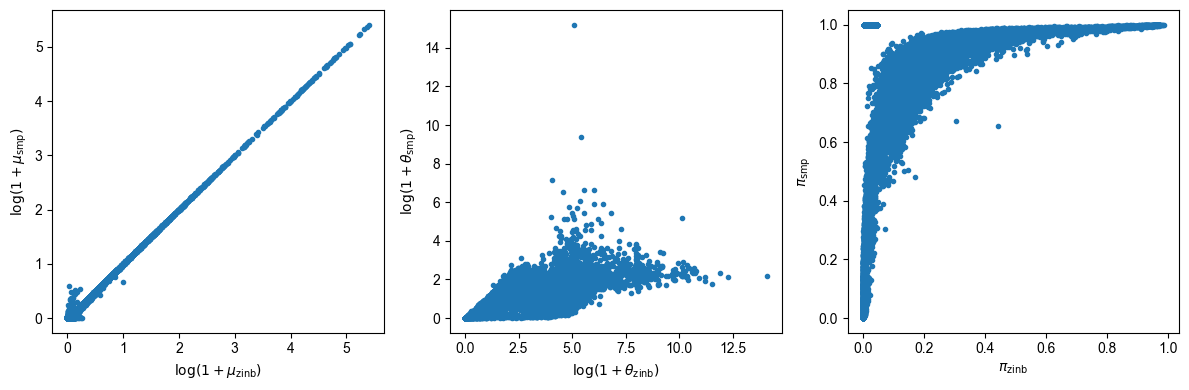

In [148]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# Plot average counts
axes[0].plot(gograph_ad.obs['average_counts.zinb'].apply(np.log1p), np.log1p(mean_smp), '.')
axes[0].set_xlabel(r'$\log (1+\mu_\text{zinb})$')
axes[0].set_ylabel(r'$\log (1+\mu_\text{smp})$')

axes[1].plot(gograph_ad.obs['dispersions.zinb'].apply(np.log1p), np.log1p(disp_smp), '.')
axes[1].set_xlabel(r'$\log (1+\theta_\text{zinb})$')
axes[1].set_ylabel(r'$\log (1+\theta_\text{smp})$')

axes[2].plot(gograph_ad.obs['dropout_rates.zinb'], pi_smp, '.')
axes[2].set_xlabel(r'$\pi_\text{zinb}$')
axes[2].set_ylabel(r'$\pi_\text{smp}$')
plt.tight_layout()
plt.show()

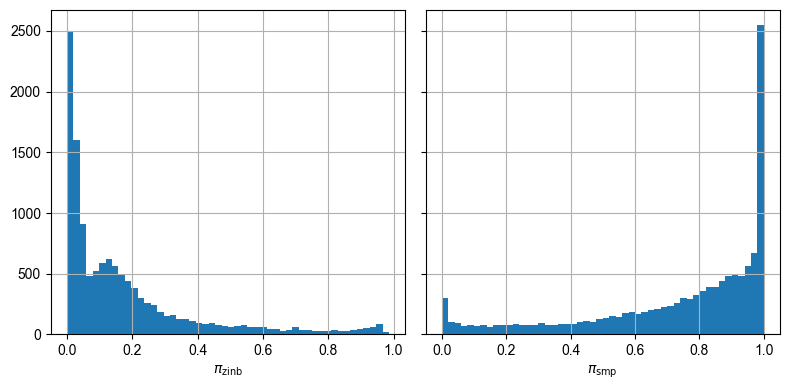

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
gograph_ad.obs['dropout_rates.zinb'].hist(ax=axes[0], bins=50)
axes[0].set_xlabel(r'$\pi_\text{zinb}$')
pd.Series(pi_smp).hist(ax=axes[1], bins=50)
axes[1].set_xlabel(r'$\pi_\text{smp}$')
plt.tight_layout()
plt.show()

In [151]:
mean_log1p_smp = np.log1p(Y_zinb).mean(axis=0)
var_log1p_smp = np.log1p(Y_zinb).var(axis=0)

In [152]:
# save E[log(1+Y)] and Var[log(1+Y)] for estimating the translation and scaling
gograph_ad.obs['mean_log1p_smp'] = mean_log1p_smp
gograph_ad.obs['var_log1p_smp'] = var_log1p_smp
gograph_ad.write_h5ad("gograph_ad_processed.h5ad")

## largest cluster

In [4]:
gograph_ad = sc.read_h5ad("gograph_ad_processed.h5ad")

In [6]:
large_clusts = gograph_ad.obs['leiden'].value_counts()[lambda x: x>500]

In [7]:
gograph_ad_largest = gograph_ad[gograph_ad.obs['leiden']==large_clusts.index[0]].copy()
gograph_ad_largest

AnnData object with n_obs × n_vars = 2985 × 18644
    obs: 'average_counts.simple', 'dispersions.simple', 'dropout_rates.simple', 'average_counts.zinb', 'dispersions.zinb', 'dropout_rates.zinb', 'leiden', 'leiden.filtered', 'mean_log1p_smp', 'var_log1p_smp'
    uns: 'leiden', 'leiden.filtered_colors', 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'

In [8]:
gograph_ad_largest.obsm['X_umap.original'] = gograph_ad_largest.obsm['X_umap'].copy()
gograph_ad_largest.obsp['distances.original'] = gograph_ad_largest.obsp['distances'].copy()
gograph_ad_largest.obsp['connectivities.original'] = gograph_ad_largest.obsp['connectivities'].copy()
gograph_ad_largest

AnnData object with n_obs × n_vars = 2985 × 18644
    obs: 'average_counts.simple', 'dispersions.simple', 'dropout_rates.simple', 'average_counts.zinb', 'dispersions.zinb', 'dropout_rates.zinb', 'leiden', 'leiden.filtered', 'mean_log1p_smp', 'var_log1p_smp'
    uns: 'leiden', 'leiden.filtered_colors', 'neighbors', 'umap'
    obsm: 'X_umap', 'X_umap.original'
    obsp: 'connectivities', 'distances', 'distances.original', 'connectivities.original'

In [9]:
sc.pp.filter_genes(gograph_ad_largest, min_cells=1)
# fix unknown error
gograph_ad_largest.obsm['dense_X'] = gograph_ad_largest.X.toarray()
sc.pp.neighbors(gograph_ad_largest, use_rep='dense_X', n_neighbors=30, metric='jaccard')
sc.tl.umap(gograph_ad_largest)
sc.tl.leiden(gograph_ad_largest, flavor='igraph', n_iterations=2, resolution=0.5)
del gograph_ad_largest.obsm['dense_X']

In [10]:
gograph_ad_largest

AnnData object with n_obs × n_vars = 2985 × 6387
    obs: 'average_counts.simple', 'dispersions.simple', 'dropout_rates.simple', 'average_counts.zinb', 'dispersions.zinb', 'dropout_rates.zinb', 'leiden', 'leiden.filtered', 'mean_log1p_smp', 'var_log1p_smp'
    var: 'n_cells'
    uns: 'leiden', 'leiden.filtered_colors', 'neighbors', 'umap'
    obsm: 'X_umap', 'X_umap.original'
    obsp: 'connectivities', 'distances', 'distances.original', 'connectivities.original'

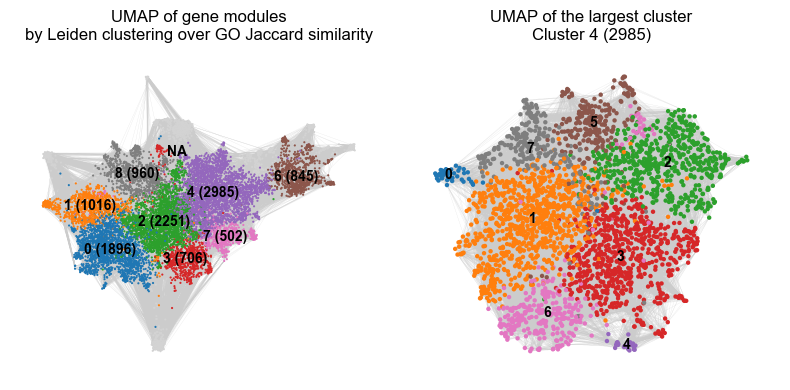

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
sc.pl.embedding(
    gograph_ad, 
    basis='umap',
    color='leiden.filtered', 
    legend_loc='on data', 
    edges=True,
    edges_color='#cccccc',
    frameon=False, 
    show=False,
    ax=axes[0]
)
axes[0].set_title('UMAP of gene modules\nby Leiden clustering over GO Jaccard similarity')
sc.pl.embedding(
    gograph_ad_largest, 
    basis='umap',
    color='leiden', 
    legend_loc='on data', 
    edges=True,
    edges_color='#cccccc',
    frameon=False, 
    show=False,
    ax=axes[1]
)
axes[1].set_title(f'UMAP of the largest cluster\nCluster {gograph_ad_largest.obs["leiden.filtered"].unique()[0]}')
plt.tight_layout()
plt.savefig('figs/gograph_ad_largest_umap.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
gograph_ad_largest.write_h5ad("gograph_ad_largest.h5ad")